In [133]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3


In [134]:
#1. import databse/data
conn = sqlite3.connect('customer_churn.db')


sql_query = """           
        SELECT name
        FROM sqlite_master
        WHERE type='table'
"""

tables = pd.read_sql(sql_query,conn) 
# create dataframe for each table
for table_name in tables['name']: 
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)  
    globals()[f"df_{table_name}"] = df 
    print(f"Created dataframe: df_{table_name}")

conn.close()
 

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [135]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
   
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query,conn)
    print("Columns:")
    print(columns['name'].tolist())

    
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']



# 2. Data Cleaning

In [136]:

df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [137]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [138]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [139]:
#a.rename column to customer name
#b. drop columns- interest and pincode
#c. change dob- datatype
#d. data standardisation - gender(women and female written)
#e. fix missing values - country

In [140]:
#a.rename column to customer name

df_db_customer.rename(columns = {'name':'customer_name'}, inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [141]:
#b. drop columns- interest and pincode

df_db_customer.drop(columns=['interests','pincode'], inplace=True)

In [142]:
#c. change dob- datatype

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])  
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [143]:
#d. data standardisation - gender

df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [144]:
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male','Women' : 'Female'})


In [145]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [146]:
#e. fix missing values - country
df_db_customer['country'].isna()  

0     False
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8      True
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
Name: country, dtype: bool

In [147]:

df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [148]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [149]:
# country and state unique value pair
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()


In [150]:
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))


In [151]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [152]:

df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [153]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [154]:

date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [155]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [156]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [157]:

df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [158]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [159]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [160]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [161]:
df_db_support['complaint_date'] =pd.to_datetime(df_db_support['complaint_date'])

In [162]:
df_db_support['complaint_date']

0   2024-08-28
1   2024-08-28
2   2024-01-20
3   2025-03-18
4   2024-11-01
5   2024-04-10
6   2024-09-27
7   2024-09-13
8   2024-09-14
Name: complaint_date, dtype: datetime64[ns]

In [163]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


# 3. Feature Engineering and Data Analysis

In [164]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34


In [165]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [166]:
df_db_subscription['churn_flag']

0     0
1     1
2     0
3     0
4     1
5     0
6     1
7     0
8     0
9     0
10    0
11    1
12    0
13    1
14    0
15    0
16    0
17    0
18    1
19    0
20    0
Name: churn_flag, dtype: int64

In [167]:
#churn flag- 1,0
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [168]:
df_db_subscription['churn_flag']

0     0
1     1
2     0
3     0
4     1
5     0
6     1
7     0
8     0
9     0
10    0
11    1
12    0
13    1
14    0
15    0
16    0
17    0
18    1
19    0
20    0
Name: churn_flag, dtype: int64

In [169]:

df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [170]:
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

In [171]:
df_db_subscription.shape

(21, 12)

In [172]:
df.shape



(23, 20)

In [173]:
df.head


<bound method NDFrame.head of     customerid subscription_start_date subscription_type renewal_date  \
0   0002-ORFBO              2021-03-15          Refferal   2025-03-15   
1   0003-MKNFE              2020-08-01              Paid   2024-08-01   
2   0003-MKNFE              2020-08-01              Paid   2024-08-01   
3   0004-TLHLJ              2022-11-20           Organic   2025-11-20   
4   0011-IGKFF              2019-05-10              Paid   2025-05-10   
5   0013-EXCHZ              2023-01-05          Refferal   2024-01-05   
6   0013-MHZWF              2022-06-18              Paid   2025-06-18   
7   0013-SMEOE              2021-09-30          Refferal   2024-09-30   
8   0014-BMAQU              2020-02-14           Organic   2025-02-14   
9   0015-UOCOJ              2023-07-22           Organic   2024-07-22   
10  0016-QLJIS              2022-04-03           Organic   2025-04-03   
11  0017-DINOC              2021-12-01           Organic   2025-12-01   
12  0017-IUDMW       

In [174]:
df_db_subscription['customerid'].nunique()

21

In [175]:
df_db_customer['customerid'].nunique()

21

In [176]:
df_db_support['customerid'].nunique()

7

In [177]:
df_db_support['customerid'].size

9

In [178]:

df.head(21)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN


In [179]:
df_db_subscription.head(23)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,41,0


In [180]:
df_db_support.head(21)

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [181]:
df_db_customer.head(21)

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [182]:

df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [183]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep = 'last')

In [184]:
df_db_support['customerid'].size

7

In [185]:
#merge df
df = (df_db_subscription
      .merge(df_db_customer, on = 'customerid',how = 'left')
      .merge(df_db_support, on = 'customerid' , how = 'left'))

In [186]:
df.shape

(21, 21)

In [187]:
df.to_csv('exported_churn_data.csv',index = False)

# Data Analysis


In [188]:
#1. Churn Rate


In [189]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [190]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ",round(churn_rate,2),"%")

Churn Rate =  28.57 %


In [191]:
#2. Retention Rate
retention_rate = 100-churn_rate
print("Retention Rate= ", round(retention_rate,2),"%") 

Retention Rate=  71.43 %


In [192]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [193]:
#3. Churn by plan type
churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct')

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [194]:
# 4. ARPU: Average Revenue Per User
arpu = df['monthly_charges'].mean()
print('ARPU = ',round(arpu,2))

ARPU =  18.85


In [195]:
#5.customer age
today = pd.Timestamp.today()
df['age']= ((today-df['dob'])/365).dt.days.round(2)
print(df['age'].astype(str) + 'years')

0     44years
1     30years
2     48years
3     25years
4     36years
5     37years
6     50years
7     27years
8     41years
9     32years
10    29years
11    45years
12    21years
13    34years
14    46years
15    40years
16    32years
17    26years
18    42years
19    35years
20    49years
Name: age, dtype: object


In [196]:
#6.Avg Customer Tenure
# count of days users has used our service: cancellation date else current date
today = pd.Timestamp.today()
 

df['tenure_days'] = np.where(
       df['cancellation_date'].notna(),   
    
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,   

    (today- df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure(Days) ", avg_tenure.round(0))

Avg Tenure(Days)  1547.0


In [197]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'tenure_days'],
      dtype='object')

In [198]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,44,2021.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,30,1501.0


In [199]:
#7. Revenue at risk: revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()

print("Revenue at Risk (Rs.'')", revenue_at_risk)

Revenue at Risk (Rs.'') 73.94


In [200]:
#8. Esclation Rate
df['escalations'].unique()  


array([nan, 'Y', 'N'], dtype=object)

In [201]:
escalation_rate = (df['escalations']=='Y').mean()*100

In [202]:
print("Escalation Rate =", round(escalation_rate,2),"%")

Escalation Rate = 19.05 %


In [203]:
#9. Avg complaint per user
avg_complaints = (
    df['complaint_count'].sum() / df['customerid'].nunique()
)

print("Avg Complaints Per User =", round(avg_complaints, 2))

Avg Complaints Per User = 0.43


In [204]:
#10. Correlation Escalation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y',1,0) 
corr_df = df[['escalations','churn_flag']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
print("Correlation between escalation vs churn is =",round(correlation,2))


Correlation between escalation vs churn is = 0.77


In [205]:
df['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [206]:
#11. Churn risk - create a column using existing col
conditions = [
    (df['churn_score']<50),
    (df['churn_score']>=50)  & (df['churn_score']<70),
    (df['churn_score']>=70)
]

choices = ['low', 'med','high']

df['churn_risk'] = np.select(conditions,choices, default = 'unknown')

In [207]:
df[['churn_risk','churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


# Visualization using Matplotlib

In [208]:
df_visual = df.copy()

In [209]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [210]:
df_visual.shape

(21, 24)

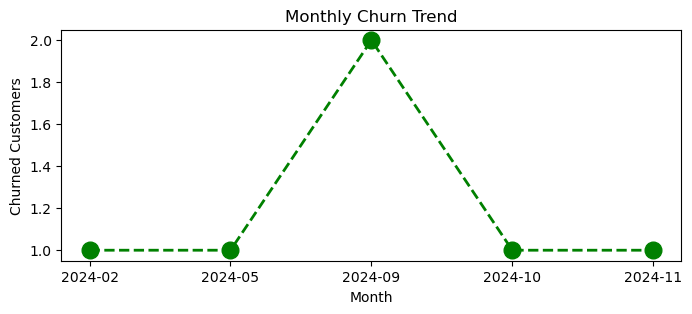

In [211]:
# 4.1 Monthly Churn Trend(Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()   

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str),  churn_trend.values, color = 'green' , marker = 'o', linestyle = 'dashed', linewidth=2,markersize =12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()


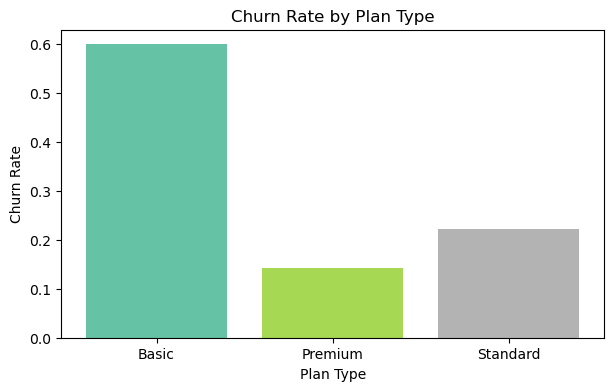

In [212]:
# 4.2 Churn by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))    

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)  

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate')

plt.show()

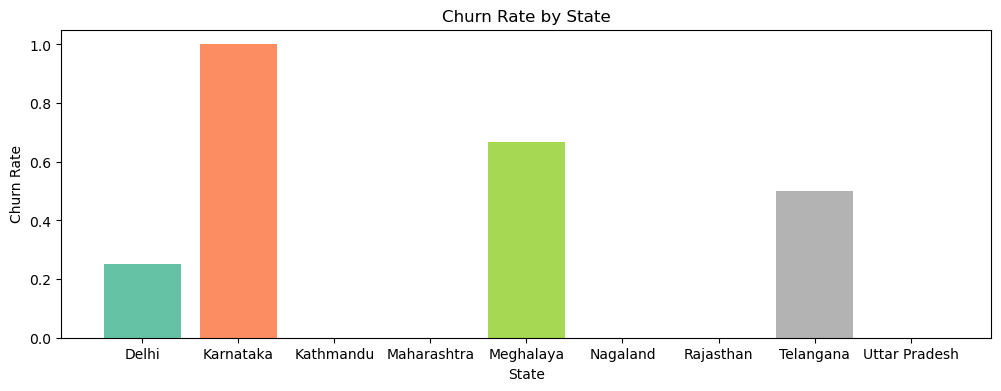

In [213]:
# 4.3 Churn by States

churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(12,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)  

plt.title('Churn Rate by State')
plt.xlabel('State')
plt.ylabel('Churn Rate')

plt.show()

In [214]:
df.head(21)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,44,2021.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,30,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,48,1406.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,25,2696.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,36,419.0,high
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,...,Delhi,Female,1988-12-10,2025-03-18,0,90.0,1.0,37,1561.0,low
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,Meghalaya,Female,1976-09-21,2024-11-01,0,30.0,1.0,50,1142.0,high
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,...,Rajasthan,Male,1999-03-14,NaT,0,NaN,NaN,27,2416.0,low
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,...,Kathmandu,Female,1985-07-07,NaT,0,NaN,NaN,41,1162.0,low
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,...,Kathmandu,Male,1993-10-29,NaT,0,NaN,NaN,32,1637.0,low


# Data Visualization with Seaborn

In [215]:
# Heatmap (correlation matrix)

In [216]:
#encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [217]:
#df_encoded =
df_encoded = df_visual[
    ['plan_type','contract_type','churn_score',
     'churn_flag','churn_risk','escalations']
]



In [218]:
df_encoded.head(21)

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1
5,Standard,Annual,22,0,low,0
6,Basic,Monthly,79,1,high,0
7,Premium,Annual,5,0,low,0
8,Standard,Monthly,34,0,low,0
9,Basic,Annual,41,0,low,0


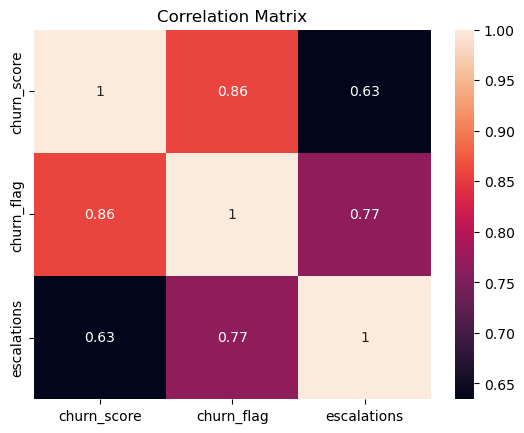

In [221]:

sns.heatmap(df_encoded.corr(numeric_only=True), annot=True)
plt.title('Correlation Matrix')
plt.show()

In [224]:
print(df_visual.shape)
print(df_encoded.shape)

(21, 25)
(21, 6)


In [225]:
df_encoded.head(21)

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1
5,Standard,Annual,22,0,low,0
6,Basic,Monthly,79,1,high,0
7,Premium,Annual,5,0,low,0
8,Standard,Monthly,34,0,low,0
9,Basic,Annual,41,0,low,0


In [226]:
df_visual['plan_type'].unique()

array(['Standard', 'Premium', 'Basic'], dtype=object)

In [227]:
df_visual['contract_type'].unique()

array(['Annual', 'Monthly'], dtype=object)

In [228]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'med'], dtype=object)

In [229]:
#mothod of encoding
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head(21)

order_mappings = {'plan_type': ['Basic','Standard','Premium'] ,  
                  'contract_type': ['Monthly','Annual'],
                  'churn_risk' : ['low','med','high']
                 }

for col, order in order_mappings.items():   
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'),categories = order, ordered=True).codes  


In [230]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


In [231]:
df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head(21)

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1
5,Standard,Annual,22,0,low,0
6,Basic,Monthly,79,1,high,0
7,Premium,Annual,5,0,low,0
8,Standard,Monthly,34,0,low,0
9,Basic,Annual,41,0,low,0


<Axes: >

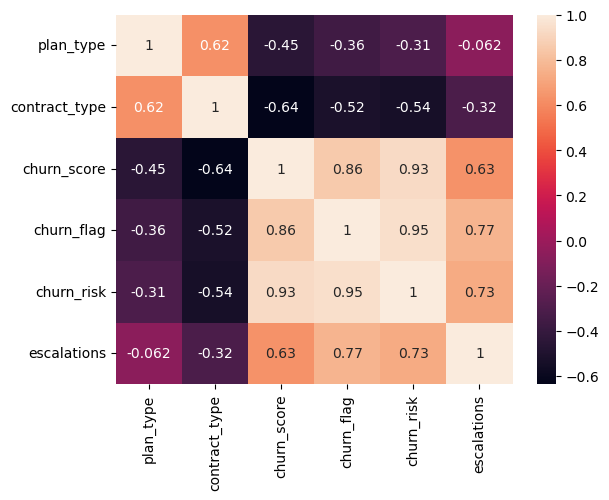

In [232]:
sns.heatmap(df_encoded.corr(), annot=True)

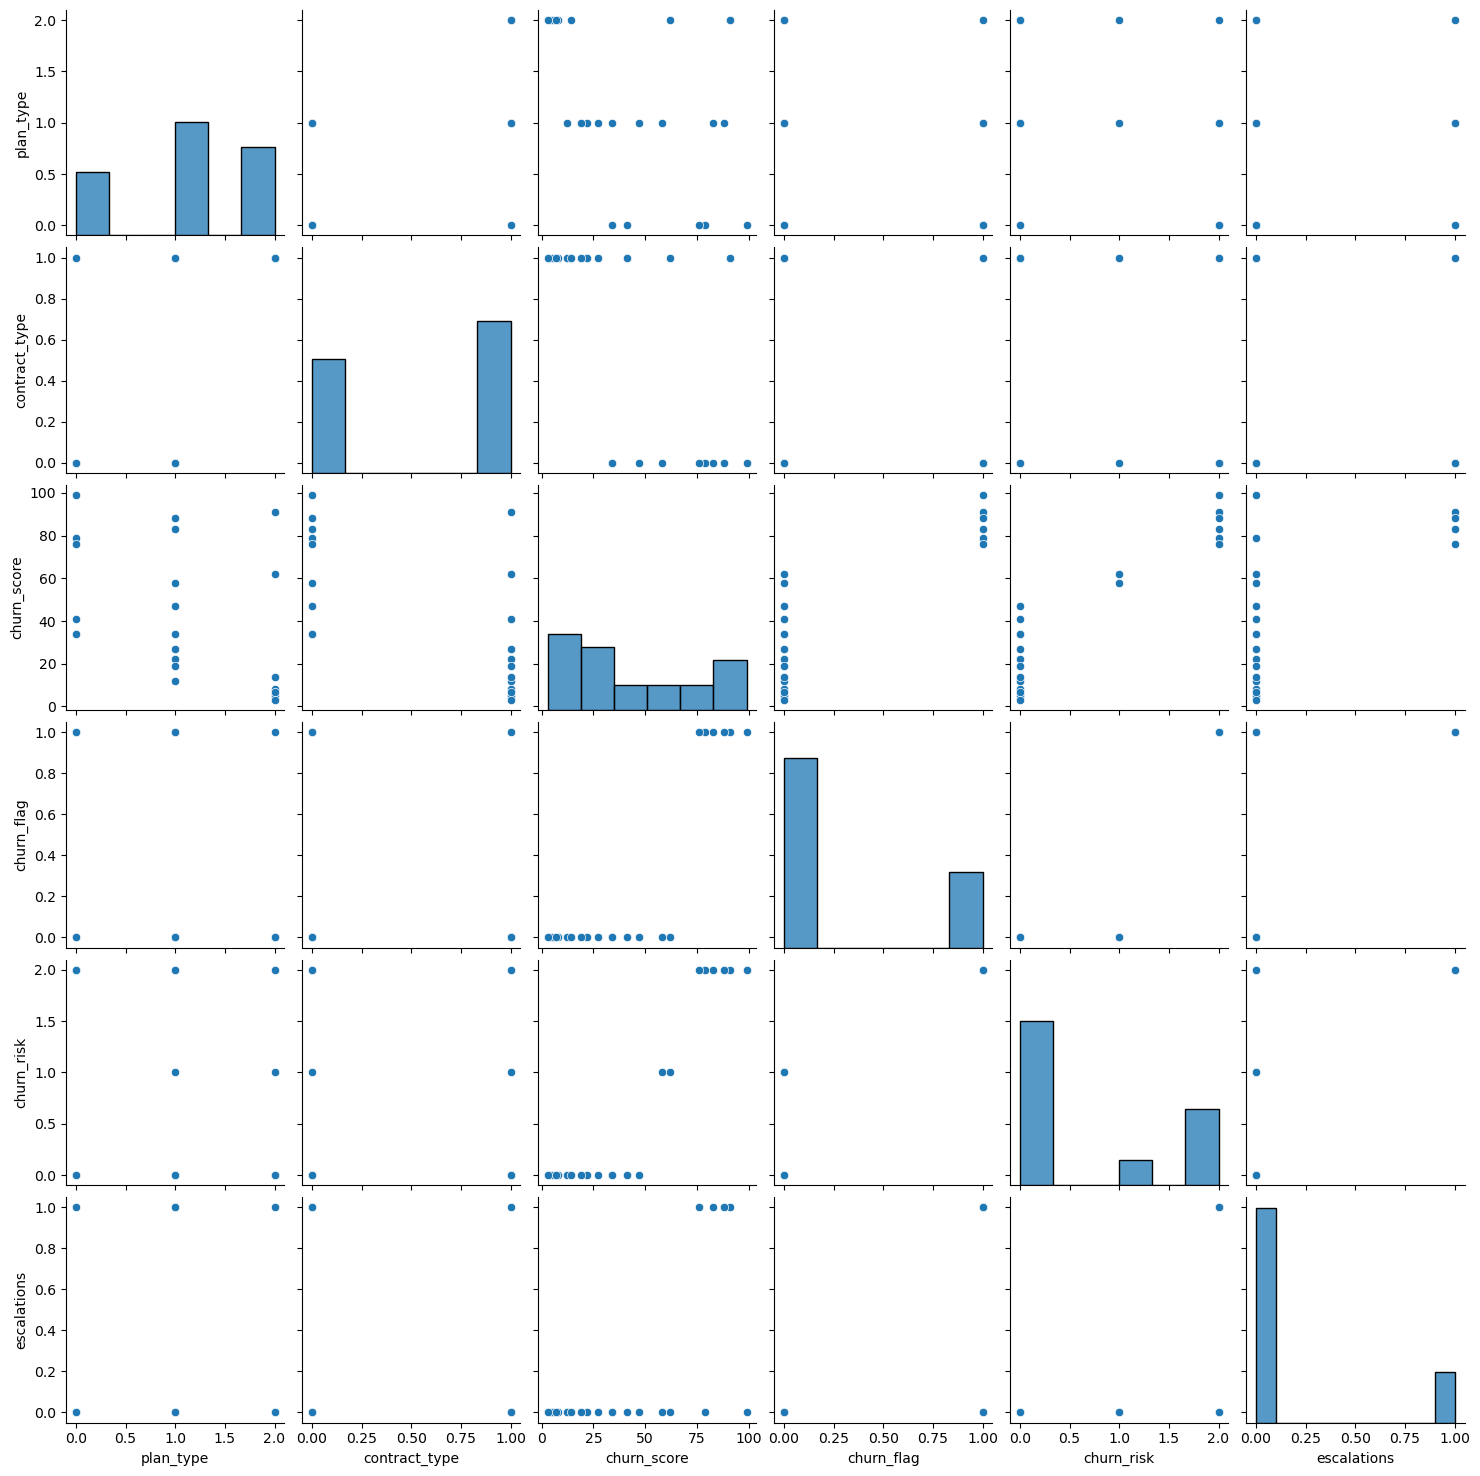

In [233]:
# pairplot  - relationship with a dataset
sns.pairplot(df_encoded)

In [234]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

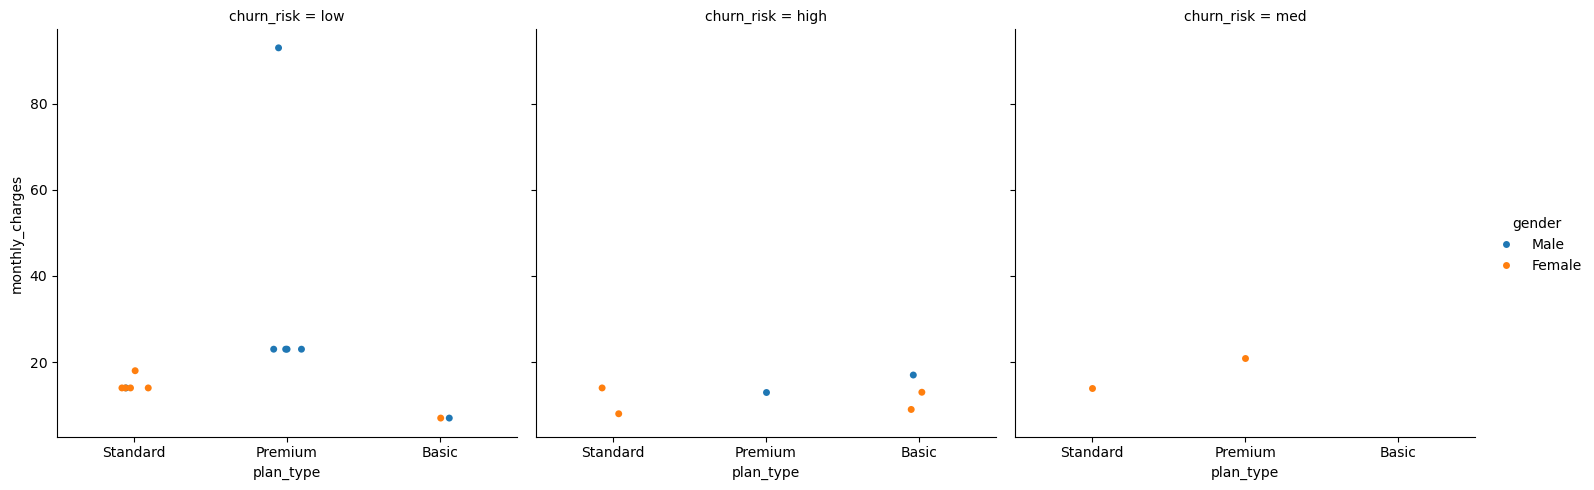

In [235]:
# facegrid plot/ catplot - multi dim comparison
sns.catplot(data=df_visual,
           x='plan_type',
           y='monthly_charges',
           hue='gender',
           col='churn_risk')

In [236]:
#pivot table

In [237]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [238]:

pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc='mean'
).reset_index()   #reset_index : index reset krdega aur 0,1,2...

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [239]:
pd.pivot_table(
    data=df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc= {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
).reset_index()  #

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


# Working with SQL in Python(pandas


In [240]:
#crete db in sql
conn = sqlite3.connect('test_database.sqlite')


#table details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

# commit and save
conn.commit()

OperationalError: table users already exists

In [241]:
#insert data

cursor = conn.cursor()

#write sql query to insert records in sql table

cursor.execute(
    """
        INSERT INTO users VALUES
        ('Madhav','India',5000),
        ('Rishabh','Germany',2500),
        ('Vishakha','India',3500)
        
    """
)

# commit and save
conn.commit()

print("Data Inserted successfully!")

Data Inserted successfully!


In [242]:
# check inserted data in table
conn = sqlite3.connect('test_database.sqlite')
query = """SELECT * FROM users"""

df_results = pd.read_sql(query,conn)

df_results.head()

,first_name,country,budget
0,Madhav,India,5000
1,Rishabh,Germany,2500
2,Vishakha,India,3500
3,Madhav,India,5000
4,Rishabh,Germany,2500


In [243]:
# aggregation
query = """
        SELECT country,sum(budget) as total_budget
        FROM users
        GROUP BY country
"""

df_agg = pd.read_sql(query,conn)
df_agg

,country,total_budget
0,Germany,10000
1,India,34000


In [244]:

conn.close()